In [ ]:
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader,TensorDataset
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

#设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'SimSun']  # 中文字体列表
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

file_path = "Admission_Predict.csv"
df = pd.read_csv(file_path)



In [20]:
#清理列名多余的空格
df.columns = [col.strip() for col in df.columns]
#删除无用列
df.drop(columns= ['Serial No.'],inplace = True)

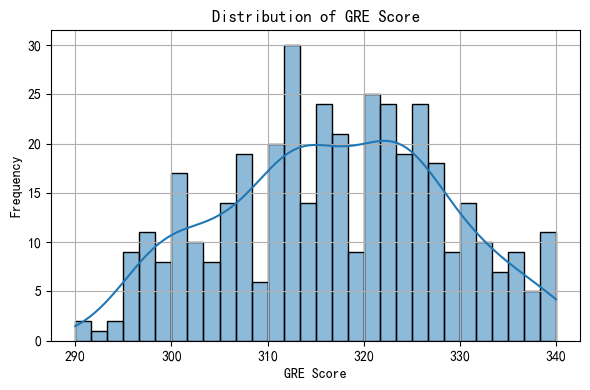

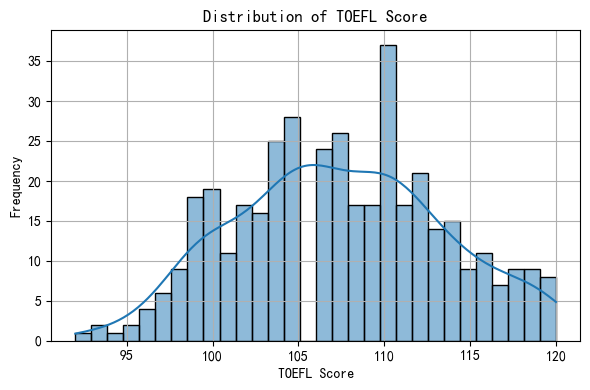

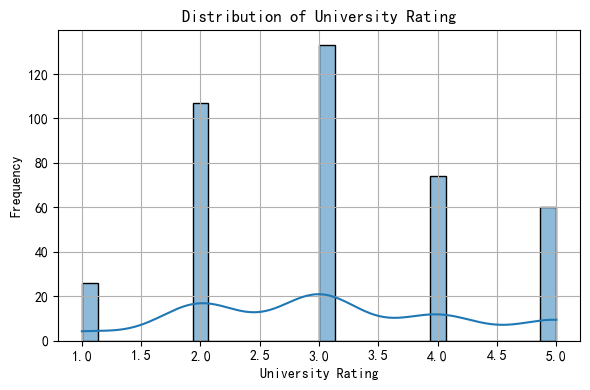

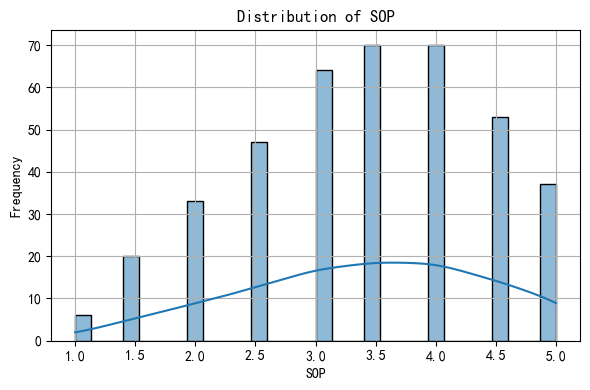

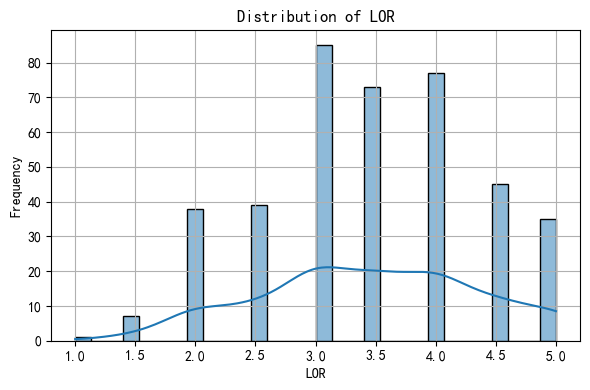

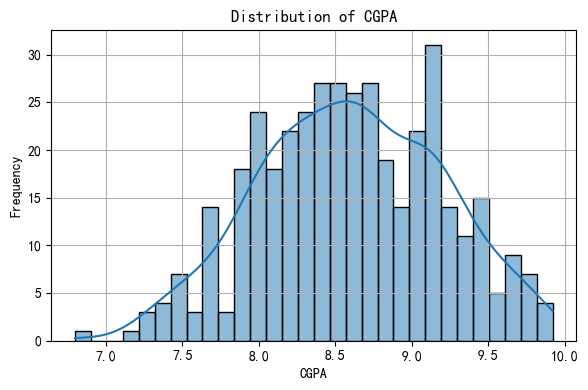

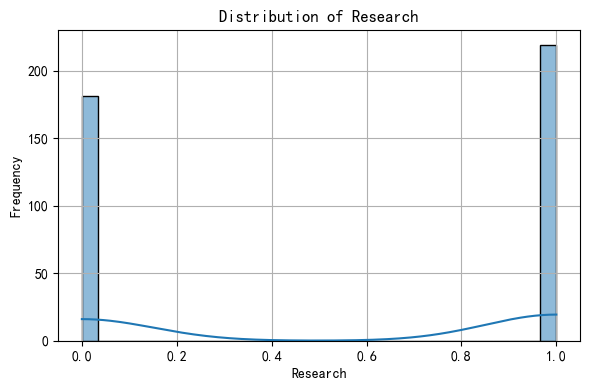

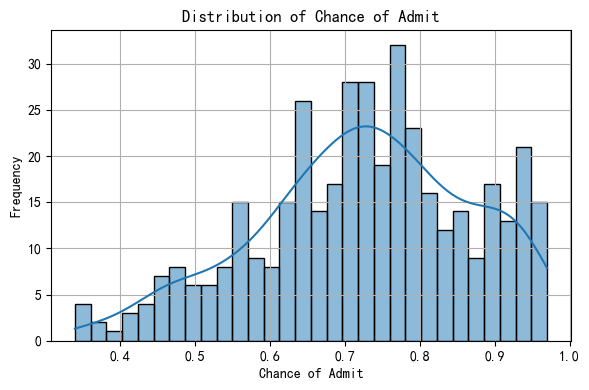

In [21]:
for col in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df,x=col,kde=True,bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    
    plt.show()

In [22]:
#特征和目标变量
X = df.drop(columns=['Chance of Admit'])
y = df['Chance of Admit']

In [23]:
#数据标准化 因为不同特征的量纲，它的取值范围是不一样的 把特征分为均值为0，标准差为1的分布
#标准化是数据预处理的一种常用方法，目的是将特征缩放到相同的尺度，以提高模型的训练效果和收敛速度
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  #计算均值和标准差，并进行标准化
#划分训练集和测试集
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)
# 转换为张量
# PyTorch 中的张量是多维数组，类似于 NumPy 数组，但可以在 GPU 上进行高效计算
# torch.tensor() 将 NumPy 数组或其他数据结构转换为 PyTorch 张量
# dtype=torch.float32 指定数据类型为 32 位浮点数，适合深度学习模型的输入
# view(-1, 1) 将一维张量转换为二维张量，-1 表示自动计算行数，1 表示列数
# 这样做是为了确保标签 y_train 和 y_test 的形状符合模型的要求，通常模型期望输入为二维张量（样本数, 特征数），
# 但标签通常是一维的（样本数,），所以需要将其转换
# 这里的转换是为了确保模型在训练时能够正确处理标签数据
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [ ]:
# 构建数据加载器
# batch_size每次迭代用多少个样本来计算梯度，小（如 1 或 16）学习更细致、泛化好，但训练慢、不稳定、噪声大；大（如 128 或 512）稳定、速度快但泛化能力差、内存占用大；32（经验值）稳定性 + 泛化折中好，是深度学习中常用默认值
# shuffle=True每个 epoch 随机打乱数据顺序，避免模型学到“样本顺序的偏见”，尤其对于梯度下降，如果每次 batch 的顺序一样，很容易陷入局部最优或过拟合，shuffle=True 每一轮都会重新洗牌，使得模型泛化能力更强
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
train_loader = DataLoader(train_dataset,batch_size = 32,shuffle = True)
#shuffle = true 是为了打乱数据顺序，避免模型学到“样本顺序的偏见”

In [32]:
#定义线性回归模型
class LinearRegressionModel(torch.nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear=torch.nn.Linear(input_dim, 1)
        #input_dim(x的元数) -> 1个y输出
    def forward(self,x):
        return self.linear(x)
#创建一个线性回归模型实例
# X.shape[0] 是样本的数量，比如 400 行样本；X.shape[1] 是特征的数量，比如 7 个特征（GRE 分数、TOEFL 分数、大学排名、SOP 等）；
# 所以 X.shape[1] 其实就是模型输入的 维度（即特征个数）
model = LinearRegressionModel(input_dim=X.shape[1])

In [33]:
# 定义损失函数和优化器

# 定义损失函数（Loss Function）为均方误差损失（MSE, Mean Squared Error）
criterion = nn.MSELoss()

# 定义优化器（Optimizer）,随机梯度下降,学习率为 0.01，表示每次更新参数时走的“步长”，实际上用的是 小批量随机梯度下降，因为你传入的是小批量数据
# 0.01 是一个经验值，其实并没有一个放之四海而皆准的值
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
# 想用Adam？可以试试
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [34]:
# 用于可视化的记录变量
train_losses = []

In [37]:
#训练模型
epochs = 100
#遍历每一个epoch（训练周期）
for epoch in range(epochs):
    epoch_loss = 0.0
    #遍历训练数据，每次获取一个batch(小批量)
    for batch_X,batch_y in train_loader:
        #第一步：清空上一轮梯度数据（避免累加）
        optimizer.zero_grad()
        #第二步：将输入数据喂入模型，得到预测输出
        y_pred = model(batch_X)
        #第三步：根据预测结果和真实值计算当前batch的损失
        loss = criterion(y_pred,batch_y)
        #第四步：反向传播，计算每个参数的梯度
        loss.backward()
        #第五步：使用优化器，根据梯度更新模型参数
        optimizer.step()

    #计算当前epoch的平均损失值(所有batch的平均)
    avg_loss = epoch_loss/len(train_loader)
    #记录损失值用于后续绘图
    train_losses.append(avg_loss)
    #每训练20个epoch打印一次损失值
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}],Loss:{avg_loss:.4f}")

Epoch [20/100],Loss:0.0000
Epoch [40/100],Loss:0.0000
Epoch [60/100],Loss:0.0000
Epoch [80/100],Loss:0.0000
Epoch [100/100],Loss:0.0000


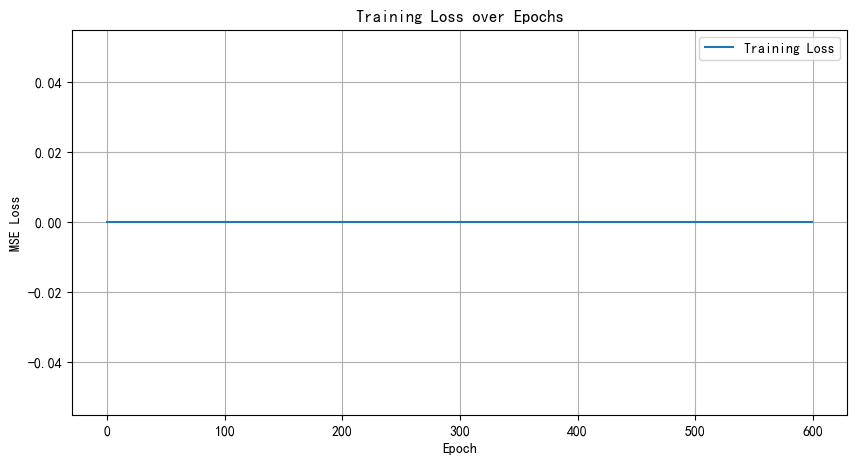

In [38]:
#可视化训练损失
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')#绘制折线图
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss over Epochs")
plt.legend()#图例
plt.grid(True)#显示网格线

plt.show()

In [ ]:
#模型评估：在测试集上进行预测
#关闭Dropout(随机丢弃部分神经元，防止过拟合)、BatchNorm(使用当前batch的均值和方差进行归一化)等训练时特有的行为，确保推理时模型表现一致、稳定，模型进入评估模式
model.eval()
#在推理或测试时禁用梯度计算，节省内存和计算资源，并加快（因为不需要反向传播）
with torch.no_grad():
    #将测试集的特征X_test_tensor是入到model中，得到预测结果
    #model(X_test_tensor)表示前向传播，输出是一个torch.Tensor，及模型预测的“录取概率”
    #.numpy()是将PyTorch 的张量(Tensor)转化为NumPy数组，方便后续用Matplotlib 或sklearn的工具进行可视化、误差分析等操作
    predictions = model(X_test_tensor).numpy()
    # 将测试集中的真实标签 y_test_tensor（是 PyTorch 的张量）转换为 NumPy 数组，便于对比预测值和真实值
    # 同样也是为了配合后续评估（比如绘图、计算 MSE、R² 等）
    y_true = y_test_tensor.numpy()

In [ ]:
#绘制预测值 vs 实际值
plt.figure(figsize=(8, 6))
plt.scatter(y_true, predictions, alpha=0.6)
plt.plot([0, 1], [0, 1], 'r--', label='Ideal Prediction')
plt.xlabel("True Chance of Admit")
plt.ylabel("Predicted Chance of Admit")
plt.title("Prediction vs. True Values")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#残差分析
residuals = y_true - predictions
plt.figure(figsize=(8, 5))
sns.histplot(residuals.flatten(), bins=30, kde=True)
plt.title("Distribution of Residuals (True - Predicted)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [ ]:
# 模型评价指标
mse = mean_squared_error(y_true, predictions)
r2 = r2_score(y_true, predictions)
print(f"Test MSE: {mse:.4f}")
print(f"Test R^2 Score: {r2:.4f}")

In [ ]:
# 展示模型权重（可解释性）
weights = model.linear.weight.detach().numpy().flatten()
feature_importance = pd.Series(weights, index=X.columns)
feature_importance.plot(kind='barh', figsize=(10, 6), title="Feature Weights in Linear Model")
plt.grid(True)
plt.show()

In [ ]:
# 保存权重文件
torch.save(model.state_dict(), "linear_regression_model.pt")